   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


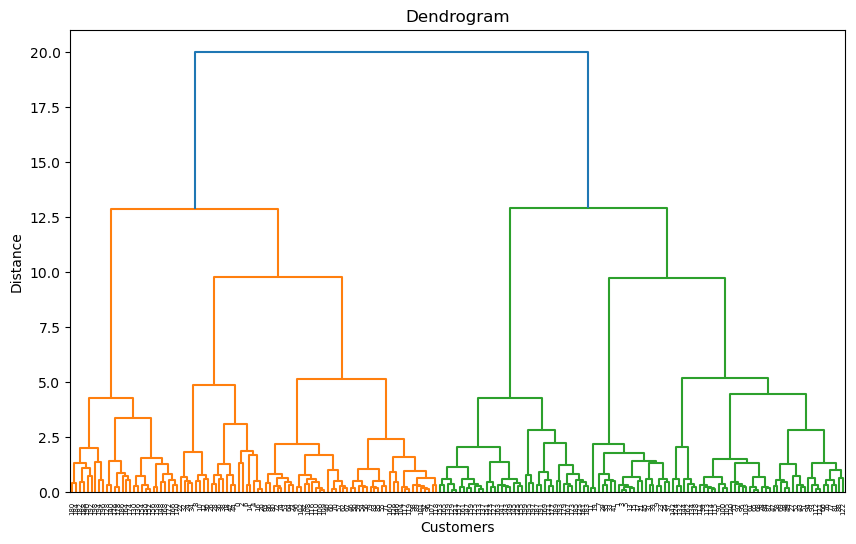


Customer Clusters:
    CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0            1   19                  15                      39        4
1            2   21                  15                      81        0
2            3   20                  16                       6        4
3            4   23                  16                      77        0
4            5   31                  17                      40        4
5            6   22                  17                      76        0
6            7   35                  18                       6        4
7            8   23                  18                      94        0
8            9   64                  19                       3        4
9           10   30                  19                      72        0
10          11   67                  19                      14        4
11          12   35                  19                      99        0
12          13   58            

In [ ]:
# Agglomerative Hierarchical Clustering
#dataset https://www.kaggle.com/datasets/shwetabh123/mall-customers

# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Step 2: Load dataset
data = pd.read_csv("Mall_Customers.csv")

# Step 3: Display dataset
print(data.head())

# Step 4: Select features
X = data[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

# Step 5: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 6: Create dendrogram
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 6))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

# Step 7: Apply Agglomerative Clustering
model = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

clusters = model.fit_predict(X_scaled)

# Step 8: Add cluster numbers to dataset
data["Cluster"] = clusters

# Step 9: Display results
print("\nCustomer Clusters:")
print(data[["CustomerID", "Age",
            "Annual Income (k$)",
            "Spending Score (1-100)",
            "Cluster"]].head(20))